<a href="https://colab.research.google.com/github/tanisaur/Fitness-Class-Prediction/blob/main/Fitness_Class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [3]:
df = pd.read_csv('fitness_class_2212.csv')
df.head().T

,0,1,2,3,4
booking_id,1,2,3,4,5
months_as_member,17,10,16,5,15
weight,79.56,79.01,74.53,86.12,69.29
days_before,8,2,14,10,8
day_of_week,Wed,Mon,Sun,Fri,Thu
time,PM,AM,AM,AM,AM
category,Strength,HIIT,Strength,Cycling,HIIT
attended,0,0,0,0,0


Goal Zone fitness club want to precict if a client will likely attend a class. They want to do this by predicting whether the member will attend the class or not.
If they can predict a member will not attend the class, they can make another space
available.

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   booking_id        1500 non-null   int64  
 1   months_as_member  1500 non-null   int64  
 2   weight            1480 non-null   float64
 3   days_before       1500 non-null   object 
 4   day_of_week       1500 non-null   object 
 5   time              1500 non-null   object 
 6   category          1500 non-null   object 
 7   attended          1500 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 93.9+ KB


##EDA

Check for missing values

Weight column is missing 20 rows.

In [5]:
df.isnull().sum()


,0
booking_id,0
months_as_member,0
weight,20
days_before,0
day_of_week,0
time,0
category,0
attended,0


In [14]:
# Fill missing 'weight' values with the median
median_weight = df['weight'].median()
df['weight'].fillna(median_weight, inplace=True)

<ipython-input-14-4910a0fea882>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['weight'].fillna(median_weight, inplace=True)


In [15]:
df.isnull().sum()

,0
booking_id,0
months_as_member,0
weight,0
days_before,0
day_of_week,0
time,0
category,0
attended,0


In [16]:
df.describe()

,booking_id,months_as_member,weight,attended
count,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,15.628667,82.585707,0.302667
std,433.157015,12.926543,12.682188,0.459565
min,1.000000,1.000000,55.410000,0.000000
25%,375.750000,8.000000,73.562500,0.000000
50%,750.500000,12.000000,80.760000,0.000000
75%,1125.250000,19.000000,89.382500,1.000000
max,1500.000000,148.000000,170.520000,1.000000


In [22]:
# Check for unique booking_id
unique_booking_ids = df['booking_id'].nunique()
print(f"Number of unique booking IDs: {unique_booking_ids}")

# Check for duplicate booking_ids
duplicate_booking_ids = df[df.duplicated(subset=['booking_id'], keep=False)]
if not duplicate_booking_ids.empty:
  print("Duplicate booking IDs found:")
  print(duplicate_booking_ids)
else:
  print("No duplicate booking IDs found.")

Number of unique booking IDs: 1500
No duplicate booking IDs found.


In [23]:
# list all unique values in categorical columns
for col in df.select_dtypes(include=['object']).columns:
    print(f"Unique values in column '{col}': {df[col].unique()}")

Unique values in column 'days_before': ['8' '2' '14' '10' '6' '4' '9' '12' '5' '3' '7' '13' '12 days' '20' '1'
 '15' '6 days' '11' '13 days' '3 days' '16' '1 days' '7 days' '8 days'
 '10 days' '14 days' '17' '5 days' '2 days' '4 days' '29']
Unique values in column 'day_of_week': ['Wed' 'Mon' 'Sun' 'Fri' 'Thu' 'Wednesday' 'Fri.' 'Tue' 'Sat' 'Monday']
Unique values in column 'time': ['PM' 'AM']
Unique values in column 'category': ['Strength' 'HIIT' 'Cycling' 'Yoga' '-' 'Aqua']


In [24]:
# Remove the word "days" and convert the column to a numerical type
df['days_before'] = df['days_before'].str.replace(' days', '').astype(int)

# Check the cleaned column
print(df['days_before'].head())


0     8
1     2
2    14
3    10
4     8
Name: days_before, dtype: int64


In [27]:
# Replace 'Wednesday' with 'Wed', 'Monday' with 'Mon', 'Fri.' with Friday
df['day_of_week'] = df['day_of_week'].replace({'Wednesday': 'Wed', 'Monday': 'Mon', 'Fri.': 'Fri'})

# Check the unique values to ensure consistency
print(df['day_of_week'].unique())


['Wed' 'Mon' 'Sun' 'Fri' 'Thu' 'Tue' 'Sat']


In [49]:
# Mapping for days of the week
day_of_week_mapping = {
    'Mon': 1,
    'Tue': 2,
    'Wed': 3,
    'Thu': 4,
    'Fri': 5,
    'Sat': 6,
    'Sun': 7
}

# Apply the mapping to the 'day_of_week' column
df['day_of_week'] = df['day_of_week'].map(day_of_week_mapping)

# Check the updated column
print(df[['day_of_week', 'day_of_week']].head())

   day_of_week  day_of_week
0            3            3
1            1            1
2            7            7
3            5            5
4            4            4


In [53]:
df['category']=df['category'].replace('-', 'unnamed')

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   booking_id        1500 non-null   int64  
 1   months_as_member  1500 non-null   int64  
 2   weight            1500 non-null   float64
 3   days_before       1500 non-null   int64  
 4   day_of_week       1500 non-null   int64  
 5   time              1500 non-null   object 
 6   category          1500 non-null   object 
 7   attended          1500 non-null   int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 93.9+ KB


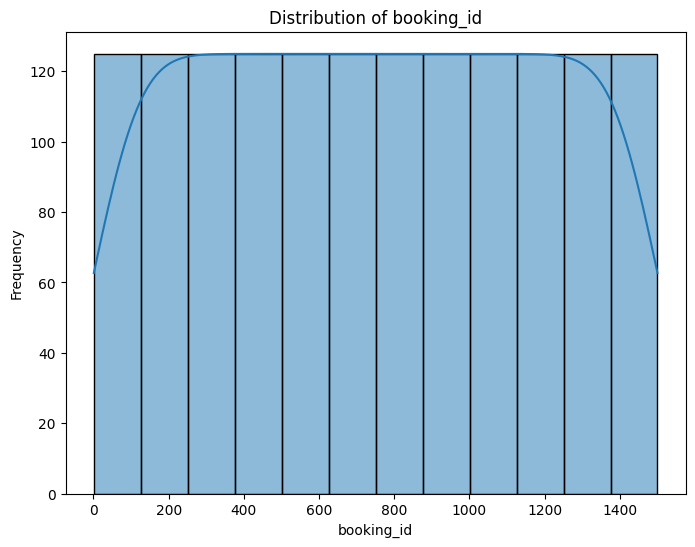

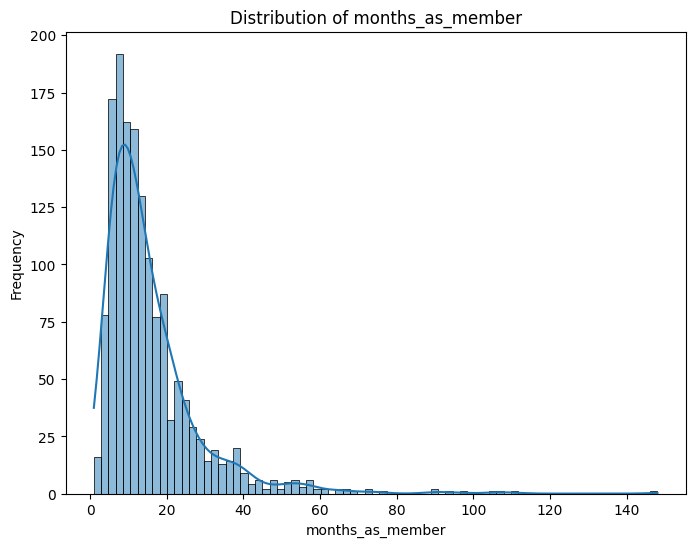

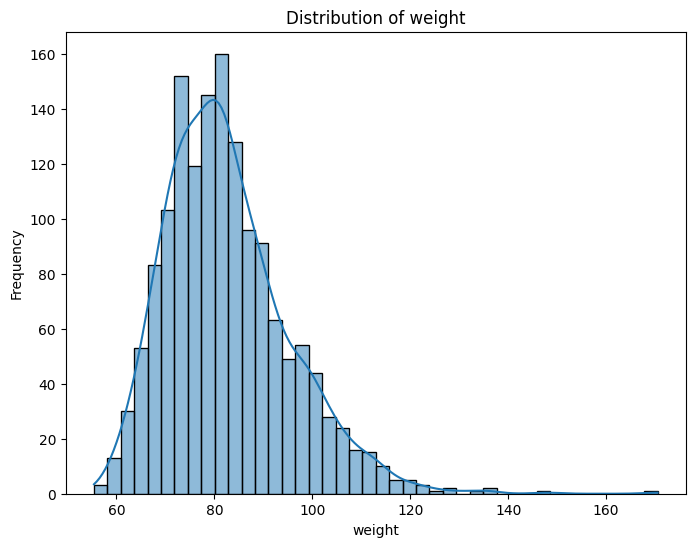

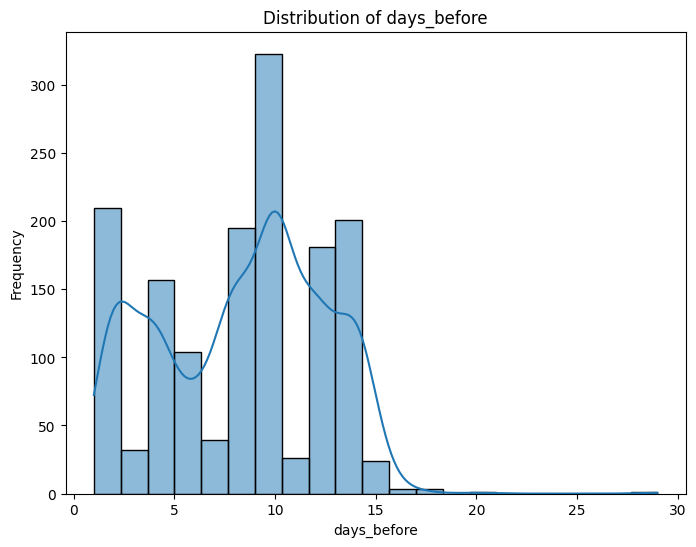

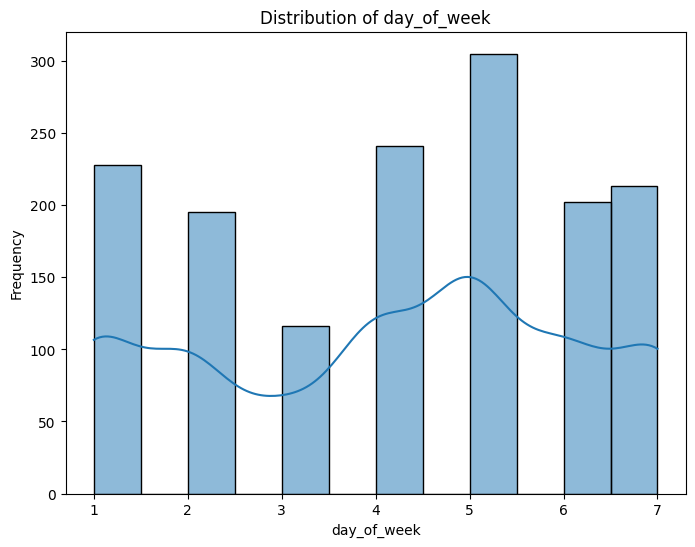

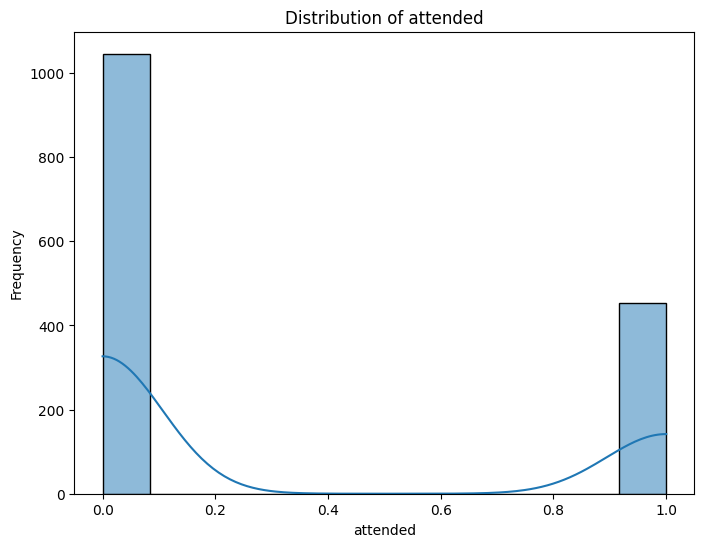

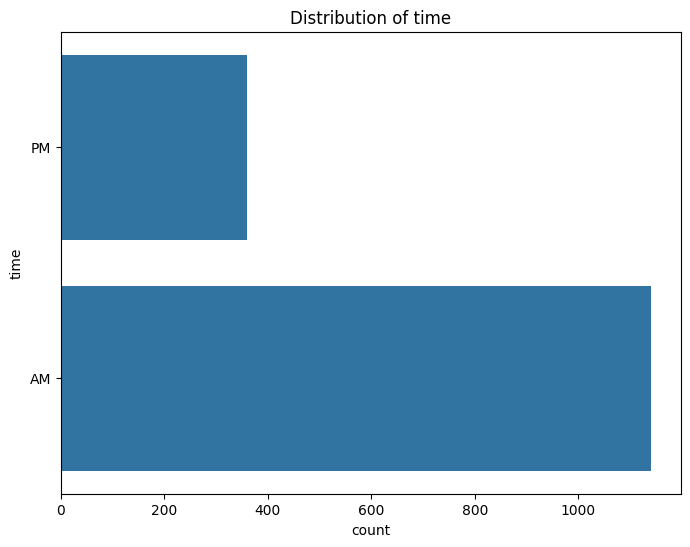

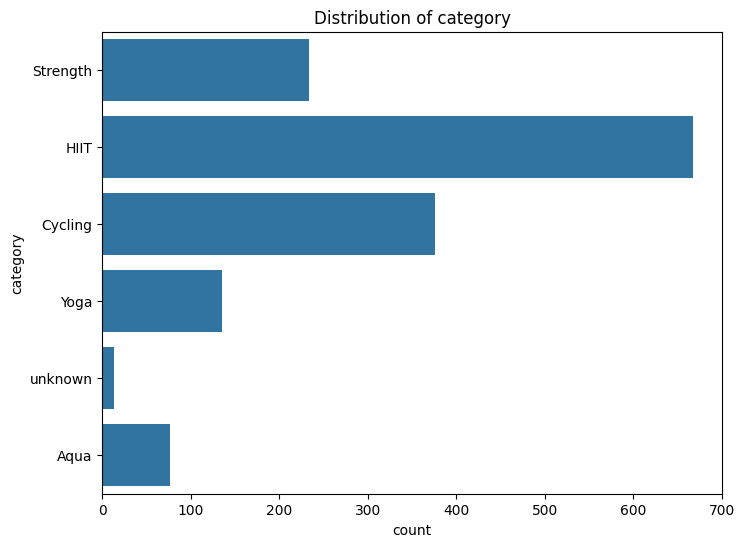

In [55]:
# Loop through each numerical column
for col in df.select_dtypes(include=np.number):
  plt.figure(figsize=(8, 6))
  sns.histplot(df[col], kde=True)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()

# Loop through each categorical column
for col in df.select_dtypes(include='object'):
  plt.figure(figsize=(8, 6))
  sns.countplot(y=col, data=df)  # Use y for better readability with longer labels
  plt.title(f'Distribution of {col}')
  plt.show()

Intial exploratory analysis reveals the following:
* More classes are booked in the morning.
* HIIT classes are most popular.
* Friday is the busiest day of the week.

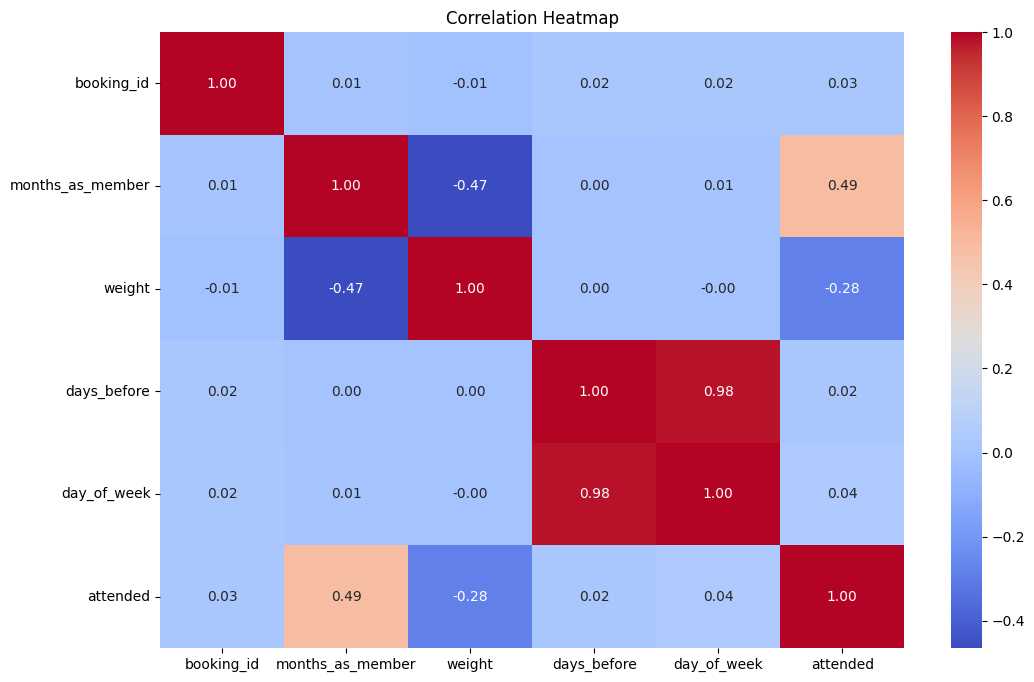

In [56]:
# Select numerical columns only
numerical_columns = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
corr_matrix = numerical_columns.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

The highest correlation is between the months_as_member and attendance.

## Feature Engineering

In [76]:
feat_df = df.copy()

#drop booking_id and weight
feat_df.drop(['weight'], axis=1, inplace=True)

feat_df.head()

,booking_id,months_as_member,days_before,day_of_week,time,category,attended
0,1,17,8,3,PM,Strength,0
1,2,10,2,1,AM,HIIT,0
2,3,16,14,7,AM,Strength,0
3,4,5,10,5,AM,Cycling,0
4,5,15,8,4,AM,HIIT,0


In [78]:
# Create a OneHotEncoder object
enc = OneHotEncoder(handle_unknown='ignore')

# Fit the encoder on the object columns
enc.fit(feat_df.select_dtypes(include=['object']))

# Transform the object columns into one-hot encoded features
num_feat = enc.transform(feat_df.select_dtypes(include=['object'])).toarray()

# Create a new DataFrame with the one-hot encoded features
num_feat_labels = list(enc.get_feature_names_out(feat_df.select_dtypes(include=['object']).columns))
ohe_df = pd.DataFrame(num_feat, columns = num_feat_labels)

# Concatenate the one-hot encoded features with the original DataFrame
feat_df = pd.concat([feat_df, ohe_df], axis=1)

# Drop the original object columns
feat_df = feat_df.drop(feat_df.select_dtypes(include=['object']).columns, axis=1)

In [97]:
feat_df.head()

,booking_id,months_as_member,days_before,day_of_week,attended,time_AM,time_PM,category_Aqua,category_Cycling,category_HIIT,category_Strength,category_Yoga,category_unknown
0,1,17,8,3,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2,10,2,1,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3,16,14,7,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,4,5,10,5,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,5,15,8,4,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [136]:
#import ML models and peformance metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
from sklearn import metrics

In [137]:
# Copy all the predictor variables into X dataframe
X = feat_df.drop(columns=['attended','booking_id'])
# Copy target into the y dataframe.
y = feat_df[['attended']]

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.7633333333333333
Precision: 0.82
Recall: 0.39805825242718446
F1 Score: 0.5359477124183006


<Axes: >

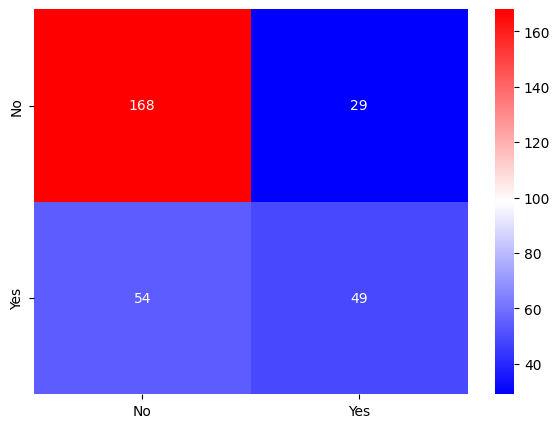

In [143]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the logistic regression model
log_reg_model = LogisticRegression()
log_reg_model.fit(X_train, y_train)

# Predict on the test set
y_pred = log_reg_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

plt.figure(figsize = (7,5))
sns.heatmap(df_cm,cmap='bwr',annot=True ,fmt='g')

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 0.7233333333333334
Precision: 0.6282051282051282
Recall: 0.47572815533980584
F1 Score: 0.5414364640883977


<Axes: >

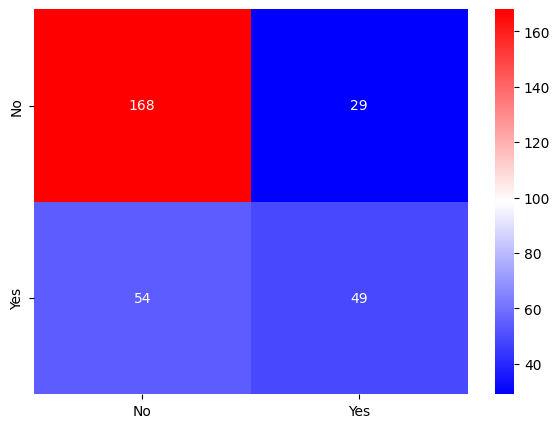

In [144]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

plt.figure(figsize = (7,5))
sns.heatmap(df_cm,cmap='bwr',annot=True ,fmt='g')


Conclusion for the models

Logistic Regression Model
* **Accuracy** is 76.3%
* **Precision**, Attendance Rate Prediction is 82%
* **Recall**, Actual Attendees is 39.8%
* **F1-Score** is 53.5%

Random Forest Model
* **Accuracy** is 72.3%
* **Precision**, Attendance Rate Prediction is 62.8%
* **Recall**, Actual Attendees is 47.5%
* **F1-Score** is 54.1%

The logistic regression model performed slightly better the random forest model